In [6]:
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
# 데이터셋 준비
iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
petal_length = df['petal length (cm)'].to_frame()
petal_width = df['petal width (cm)']
print("Iris 데이터셋")
print(df)

Iris 데이터셋
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


In [8]:

# 훈련/테스트 셋 분리
train_X, test_X, train_y, test_y = \
    train_test_split(petal_length, petal_width, test_size=0.3,\
                     random_state=1234)

# 학습 모델 정의
model = LinearRegression()

# 훈련 셋을 사용하여 모델 학습
model.fit(train_X, train_y)

# 테스트 셋을 사용하여 예측
pred_y = model.predict(test_X)
print(pred_y)

[1.56493644 1.60707034 1.98627536 0.21665191 1.2699992  0.3009197
 0.2587858  0.13238413 1.35426699 2.44974817 1.2699992  0.17451802
 2.44974817 1.39640088 0.3009197  1.10146364 2.15481093 0.3009197
 2.07054314 1.39640088 1.43853477 1.56493644 1.52280255 1.60707034
 2.19694482 0.2587858  1.69133812 1.31213309 2.11267704 0.3009197
 0.89079418 1.64920423 0.17451802 1.7756059  1.73347201 0.42732137
 0.21665191 0.34305359 0.04811635 1.01719585 0.17451802 1.52280255
 0.2587858  1.7756059  2.15481093]


In [9]:

# coefficients & Intercept
print('Coefficients: {0:.2f}, Intercept {1:.3f}'\
      .format(model.coef_[0], model.intercept_))

# mean squared error
print('Mean squared error: {0:.2f}'.\
      format(mean_squared_error(test_y, pred_y)))

# r2 score
print('R2 score: {0:.2f}'.\
      format(r2_score(test_y, pred_y)))

Coefficients: 0.42, Intercept -0.373
Mean squared error: 0.04
R2 score: 0.93


In [10]:
# 예측
print("petal_length = 1.0, petal_width =", model.predict([[1.0]]))
print("petal_length = 1.2, petal_width =", model.predict([[1.2]]))
print("petal_length = 1.4, petal_width =", model.predict([[1.4]]))

petal_length = 1.0, petal_width = [0.04811635]
petal_length = 1.2, petal_width = [0.13238413]
petal_length = 1.4, petal_width = [0.21665191]


/home/shpark/.cache/pypoetry/virtualenvs/dku-deep-learning-SAAC-9yN-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/shpark/.cache/pypoetry/virtualenvs/dku-deep-learning-SAAC-9yN-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/shpark/.cache/pypoetry/virtualenvs/dku-deep-learning-SAAC-9yN-py3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


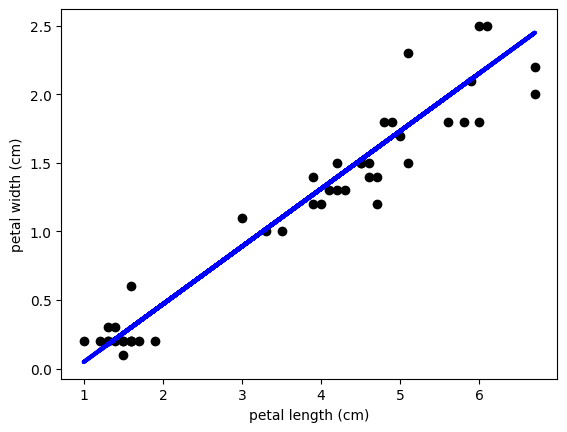

In [11]:
# 모델 시각화
plt.scatter(test_X, test_y,  color='black')
plt.plot(test_X, pred_y, color='blue', linewidth=3)
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.show()